# Encoder Comparison: Basis vs Binary vs Trig

This notebook compares the three encoders provided by `MPSFast.Encoders`
on the same Heston path dataset:

| Encoder | Sites/timestep | Physical dim `d` | Feature map |
|---------|---------------|-----------------|-------------|
| `BasisEncoder(m)` | 1 | `2^m` | None (one-hot) |
| `BinaryEncoder(m)` | `m` | 2 | None (one-hot) |
| `TrigEncoder(m, d_feat)` | 1 | `d_feat` | `K×d_feat` trig harmonics |

We compare: NLL convergence speed, bond dimensions needed, sampling fidelity, and option prices.

In [4]:
import Pkg
Pkg.activate(joinpath(@__DIR__, "../.."))
Pkg.resolve()
Pkg.instantiate()

using MPSFast
using MPSFast.Encoders
using Random, LinearAlgebra, Statistics, Printf, Distributions

  Activating project at `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl`
     Project No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Project.toml`
    Manifest No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Manifest.toml`


## 1. Generate Heston Paths

In [5]:
function simulate_heston(N, M; S0=100.0, V0=0.04, κ=2.0, θ=0.04,
                          ξ=0.3, ρ=-0.7, r=0.0, dt=1/252, rng=Random.default_rng())
    S = Matrix{Float64}(undef, N, M)
    for i in 1:N
        s = S0; v = V0
        for t in 1:M
            z1 = randn(rng); z2 = randn(rng)
            w1 = z1
            w2 = ρ * z1 + sqrt(1 - ρ^2) * z2
            v  = max(v + κ*(θ-v)*dt + ξ*sqrt(max(v,0.0)*dt)*w2, 0.0)
            s  = s * exp((r-0.5*v)*dt + sqrt(max(v,0.0)*dt)*w1)
            S[i, t] = s
        end
    end
    return S
end

rng = MersenneTwister(2024)
N_train, M = 5_000, 20
paths = simulate_heston(N_train, M; rng=rng)
println("Training paths: ", size(paths))

Training paths: (5000, 20)


## 2. Set Up Encoders

In [6]:
m = 5    # 2^4 = 16 buckets

enc_basis  = BasisEncoder(m)
enc_binary = BinaryEncoder(m)
enc_trig   = TrigEncoder(m, 8; angle_mode = :discrete_cell_pi)

for enc in (enc_basis, enc_binary, enc_trig)
    fit_grid!(enc, paths)
end

xi_basis  = encode_paths(enc_basis,  paths)
xi_binary = encode_paths(enc_binary, paths)
xi_trig   = encode_paths(enc_trig,   paths)  # same bucket indices as basis

# ── 10 % validation split (shared across encoders for fair comparison) ──────
val_frac = 0.10
N_total  = size(paths, 1)
N_val    = round(Int, val_frac * N_total)
perm_enc = randperm(MersenneTwister(0), N_total)
val_idx  = perm_enc[1:N_val];  tr_idx = perm_enc[N_val+1:end]
xi_basis_tr  = xi_basis[tr_idx,  :];  xi_basis_val  = xi_basis[val_idx,  :]
xi_binary_tr = xi_binary[tr_idx, :];  xi_binary_val = xi_binary[val_idx, :]
xi_trig_tr   = xi_trig[tr_idx,  :];   xi_trig_val   = xi_trig[val_idx,  :]
println("Train: $(length(tr_idx)) paths   Val: $(length(val_idx)) paths")
D_max = 64
println("\nEncoder overview:")
for (name, enc) in [("Basis", enc_basis), ("Binary", enc_binary), ("Trig", enc_trig)]
    Ml = chain_length(enc, M)
    d  = site_dim(enc)
    println("  ", rpad(name, 8), "  chain_length=", Ml, "  site_dim=", d,
            "  feature_map=", feature_map(enc) === nothing ? "nothing" : "$(size(feature_map(enc)))")
end

Train: 4500 paths   Val: 500 paths

Encoder overview:
  Basis     chain_length=20  site_dim=32  feature_map=nothing
  Binary    chain_length=100  site_dim=2  feature_map=nothing
  Trig      chain_length=20  site_dim=8  feature_map=(32, 8)


## 3. Train Each Encoder

In [7]:
n_epochs = 100
η        = 5e-4
ε_cut    = 1e-5
rng_init = MersenneTwister(7)

# BasisEncoder
mps_basis = init_mps(chain_length(enc_basis, M), site_dim(enc_basis), D_max; rng=rng_init)
val_nll_basis = Float64[]
nll_basis = train_mps!(mps_basis, xi_basis_tr, n_epochs, η, D_max, ε_cut;
                       verbose=false, nll_samples=500,
                       lr_schedule=cosine_lr,
                       val_data=xi_basis_val, val_samples=N_val, val_nll_log=val_nll_basis)
println("Basis  final NLL: ", round(nll_basis[end],  digits=4))

Basis  final NLL: 24.2237


In [8]:
# BinaryEncoder
mps_binary = init_mps(chain_length(enc_binary, M), site_dim(enc_binary), D_max; rng=rng_init)
val_nll_binary = Float64[]
nll_binary = train_mps!(mps_binary, xi_binary_tr, n_epochs, η, D_max, ε_cut;
                        verbose=false, nll_samples=500,
                        lr_schedule=cosine_lr,
                        val_data=xi_binary_val, val_samples=N_val, val_nll_log=val_nll_binary)
println("Binary final NLL: ", round(nll_binary[end], digits=4))

Binary final NLL: 22.9273


In [9]:
# TrigEncoder — uses Gram-weighted training
Phi_trig  = Float32.(feature_map(enc_trig))
mps_trig  = init_mps(chain_length(enc_trig, M), site_dim(enc_trig), D_max; rng=rng_init)
val_nll_trig = Float64[]
nll_trig  = train_mps!(mps_trig, xi_trig_tr, n_epochs, η, D_max, ε_cut;
                       feature_phi=Phi_trig, verbose=false, nll_samples=500,
                       lr_schedule=cosine_lr,
                       val_data=xi_trig_val, val_samples=N_val, val_nll_log=val_nll_trig)
println("Trig   final NLL: ", round(nll_trig[end],   digits=4))

Trig   final NLL: 42.2454


In [11]:
# NLL convergence table
n_done = length(nll_basis)  # all three run same n_epochs (no early stopping)
println("\nEpoch | Basis NLL  val  | Binary NLL  val  | Trig NLL  val")
for e in 1:n_done
    @printf "  %3d | %9.4f %9.4f | %10.4f %9.4f | %8.4f %8.4f\n" e nll_basis[e] val_nll_basis[e] nll_binary[e] val_nll_binary[e] nll_trig[e] val_nll_trig[e]
end


Epoch | Basis NLL  val  | Binary NLL  val  | Trig NLL  val
    1 |   48.8461   50.2556 |    48.1539   50.3499 |  45.0558  45.0625
    2 |   55.1993   55.6222 |    40.7546   43.1211 |  44.1793  43.9870
    3 |   54.2292   54.7572 |    37.4021   40.1743 |  43.7559  43.7821
    4 |   53.4210   54.1668 |    35.3475   38.3284 |  43.6409  43.5806
    5 |   53.4407   54.2249 |    34.0775   36.9193 |  43.5382  43.4869
    6 |   53.0945   53.1568 |    32.9331   35.8675 |  43.2967  43.3470
    7 |   53.2532   53.9723 |    32.2011   35.0610 |  43.3275  43.2653
    8 |   54.0701   54.3393 |    31.4505   34.3800 |  43.3147  43.1855
    9 |   52.3686   53.1634 |    30.5279   33.7496 |  43.0389  43.1470
   10 |   52.9650   53.3288 |    30.2430   33.2029 |  43.1353  43.1019
   11 |   50.9377   51.8214 |    29.6380   32.7997 |  42.8963  43.0742
   12 |   52.0684   52.4315 |    29.2362   32.4261 |  43.0327  43.0184
   13 |   51.6228   51.9592 |    28.6480   32.0182 |  42.9930  42.9834
   14 |   51.0303

### NLL convergence plot

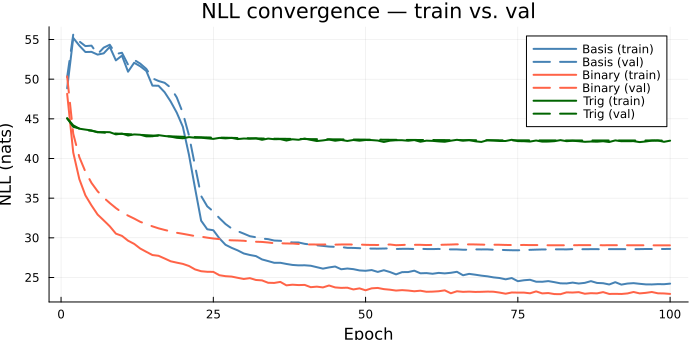

In [13]:
using Plots

epochs_ax = 1:n_done
p_nll = plot(epochs_ax, nll_basis;
    lw=2, color=:steelblue,  label="Basis (train)",
    xlabel="Epoch", ylabel="NLL (nats)",
    title="NLL convergence — train vs. val", size=(700, 340), legend=:topright)
plot!(p_nll, epochs_ax, val_nll_basis;  lw=2, ls=:dash, color=:steelblue,  label="Basis (val)")
plot!(p_nll, epochs_ax, nll_binary;     lw=2, color=:tomato,    label="Binary (train)")
plot!(p_nll, epochs_ax, val_nll_binary; lw=2, ls=:dash, color=:tomato,    label="Binary (val)")
plot!(p_nll, epochs_ax, nll_trig;       lw=2, color=:darkgreen, label="Trig (train)")
plot!(p_nll, epochs_ax, val_nll_trig;   lw=2, ls=:dash, color=:darkgreen, label="Trig (val)")
display(p_nll)

## 4. Bond Dimension Analysis

In [14]:
function bond_profile(mps)
    [size(mps[j], 3) for j in 1:length(mps)-1]
end

println("Bond dimensions:")
println("  Basis : ", bond_profile(mps_basis))
println("  Binary: ", bond_profile(mps_binary))
println("  Trig  : ", bond_profile(mps_trig))

# Entanglement entropy profiles
_, entr_basis  = bipartite_entropies(mps_basis)
_, entr_binary = bipartite_entropies(mps_binary)
_, entr_trig   = bipartite_entropies(mps_trig)

println("\nBipartite entropies (nats):")
println("  Basis  (max): ", round(maximum(filter(isfinite, entr_basis)),  digits=4))
println("  Binary (max): ", round(maximum(filter(isfinite, entr_binary)), digits=4))
println("  Trig   (max): ", round(maximum(filter(isfinite, entr_trig)),   digits=4))

Bond dimensions:
  Basis : [32, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 32]
  Binary: [2, 4, 8, 16, 32, 52, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 32, 16, 8, 4, 2]
  Trig  : [8, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 8]

Bipartite entropies (nats):
  Basis  (max): 3.0818
  Binary (max): 3.622
  Trig   (max): 3.0705


## 5. Sampling Fidelity

In [15]:
N_samp = 2_000

samp_basis,  _ = sample_paths(enc_basis,  mps_basis,  N_samp; seed=1)
samp_binary, _ = sample_paths(enc_binary, mps_binary, N_samp; seed=1)
samp_trig,   _ = sample_paths(enc_trig,   mps_trig,   N_samp; seed=1)

# Compare terminal distribution statistics
t_last = M
println("Terminal price S[M] statistics (t=", t_last, "):")
println("  Source       Mean      Std       Skew")
function stats(v)
    μ = mean(v); σ = std(v)
    sk = mean(((v .- μ)./σ).^3)
    (μ, σ, sk)
end
for (name, samp) in [("Training", paths), ("Basis", samp_basis),
                     ("Binary", samp_binary), ("Trig", samp_trig)]
    μ, σ, sk = stats(samp[:, t_last])
    @printf "  %-10s  %6.2f    %6.2f    %5.3f\n" name μ σ sk
end

Terminal price S[M] statistics (t=20):
  Source       Mean      Std       Skew
  Training     99.16      5.57    -0.320
  Basis        98.45      5.62    -0.314
  Binary       99.59      5.86    -0.349
  Trig         97.77      7.75    -0.565


## 6. Option Pricing Comparison

In [16]:
S0      = 100.0
K_atm   = 100.0
T       = M / 252

function eu_call_price(paths, K, r=0.0)
    T_loc = size(paths, 2) / 252
    exp(-r * T_loc) * mean(max.(paths[:, end] .- K, 0.0))
end

println("European ATM Call (K=", K_atm, "):")
for (name, samp) in [("Training", paths), ("Basis", samp_basis),
                     ("Binary", samp_binary), ("Trig", samp_trig)]
    p = eu_call_price(samp, K_atm)
    @printf "  %-10s  %.4f\n" name p
end

European ATM Call (K=100.0):
  Training    1.7988
  Basis       1.5487
  Binary      2.1213
  Trig        1.9308


## 7. Summary and Recommendations

| Aspect | BasisEncoder | BinaryEncoder | TrigEncoder |
|--------|-------------|--------------|-------------|
| Chain length | `M` | `M·m` | `M` |
| Per-bond cost | `O(D³d²)` | `O(D³)` | `O(D³d²)` with `d = d_feat ≪ 2^m` |
| Bond dimension needed | high | medium | low |
| Interpretability | high | medium | requires Φ inspection |
| Recommended when | `m ≤ 4`, small `M` | `m ≥ 5`, large `M` | want compact MPS with good NLL |

**Rule of thumb:** Start with `BasisEncoder(4)` for quick experiments.
Use `TrigEncoder(4, 8)` for production to reduce bond dimension.